##   Introduction
     - Problem Statement: 
   
     - Using the given data to build a ML model to automate and enhance audits, enabling real-time pattern recognition and predictive analysis.
    
     - Data: 
         - dataset is csv file.
         - data columns 1-5 audit results.


# Part 1: Data Analysis

## 1.1 Viewing data
      - shape, size
      - data types
      - missing values
      - outliers
      - and more
      
      if needed, data cleaning:
          - handle missing values
          - convert data types (str to int, categorical, datetime)
          - drop some column, samples 
          - etc.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from datetime import timedelta, datetime
import random
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn import metrics 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


In [2]:
# Uploading the data to pandas frame
audit_df = pd.read_csv("audit_dataset.csv")

#check the first five records
display(audit_df.head())

#check dataset shape
audit_df.shape

,Audit_ID,Department,Audit_Finding,Risk_Level,Audit_Date
0,1,Operations,Non-compliance,Medium,2022-03-23
1,2,Finance,Fraudulent Activity,Medium,2022-09-05
2,3,HR,Non-compliance,High,2022-09-03
3,4,Operations,Non-compliance,Medium,2022-03-27
4,5,IT,Control Weakness,High,2022-11-05


(10000, 5)

In [8]:
# data types
audit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Audit_ID       10000 non-null  int64 
 1   Department     10000 non-null  object
 2   Audit_Finding  10000 non-null  object
 3   Risk_Level     10000 non-null  object
 4   Audit_Date     10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [9]:
# data describe( )
audit_df.describe()

,Audit_ID
count,10000.00000
mean,5000.50000
std,2886.89568
min,1.00000
25%,2500.75000
50%,5000.50000
75%,7500.25000
max,10000.00000


In [11]:
# missing values
audit_df.isna().sum().sum()

0

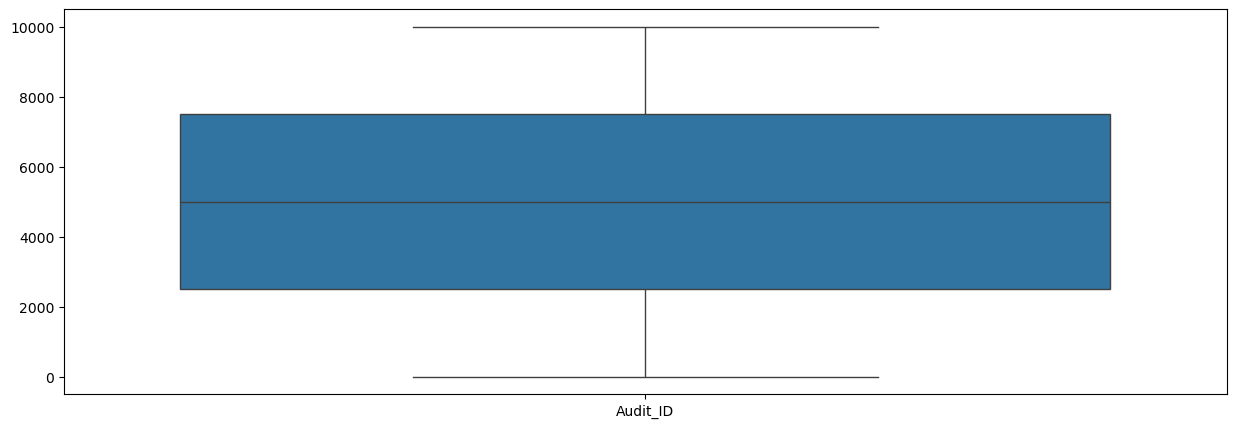

In [17]:
# outliers 
plt.figure(figsize=[15, 5])
sns.boxplot(data = audit_df)
plt.show()


## 1.2 Exploratory Data Analysis (EDA):  

 - depend on your data and your needs
    - visualization
    

In [3]:
audit_finding_counts = audit_df['Audit_Finding'].value_counts()
audit_finding_counts

Audit_Finding
Fraudulent Activity    3444
Control Weakness       3295
Non-compliance         3261
Name: count, dtype: int64

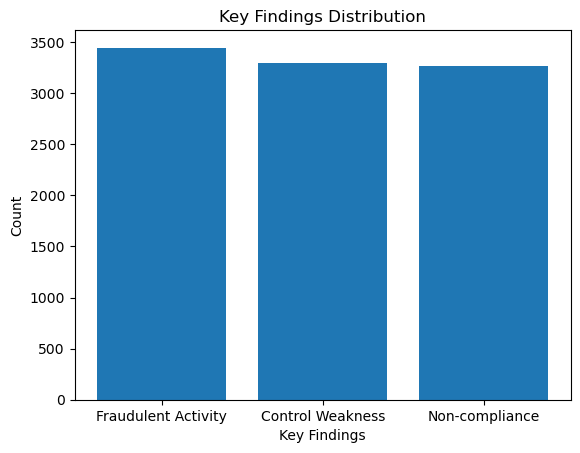

In [4]:
# Plot the key findings distribution
plt.bar(audit_finding_counts.index, audit_finding_counts.values)
plt.xlabel('Key Findings')
plt.ylabel('Count')
plt.title('Key Findings Distribution')
plt.show()

In [13]:
risk_levels = audit_df['Risk_Level'].value_counts()
risk_levels

Risk_Level
High      3377
Medium    3317
Low       3306
Name: count, dtype: int64

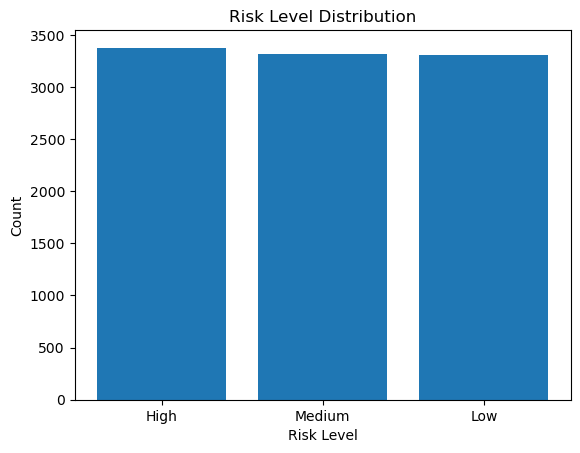

In [14]:
# Plot the risk level distribution
plt.bar(risk_levels.index, risk_levels.values)
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.title('Risk Level Distribution')
plt.show()

In [15]:
depts = audit_df['Department'].value_counts()
depts

Department
Operations    2010
HR            2007
Finance       1998
IT            1993
Marketing     1992
Name: count, dtype: int64

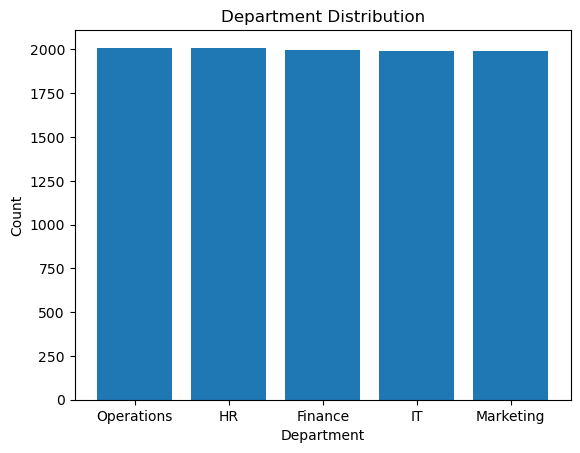

In [16]:
# Plot the department distribution
plt.bar(depts.index, depts.values)
plt.xlabel('Department')
plt.ylabel('Count')
plt.title('Department Distribution')
plt.show()

In [5]:
# Trending the data by months since the number of years is 1
# Convert the 'Audit_Date' column to datetime if it's not already in datetime format
audit_df['Audit_Date'] = pd.to_datetime(audit_df['Audit_Date'])

# Group the data by month and count the occurrences of each month
monthly_counts = audit_df.groupby(audit_df['Audit_Date'].dt.to_period('M')).size()

# Convert the period index to strings
monthly_counts.index = monthly_counts.index.astype(str)

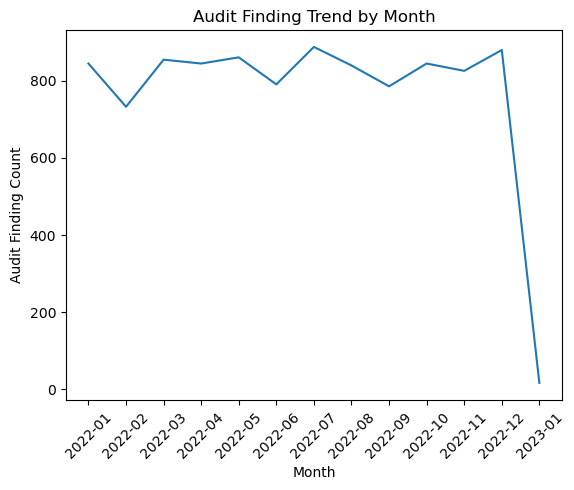

In [6]:
# Plot the data trend by months
plt.plot(monthly_counts.index, monthly_counts.values)
plt.xlabel('Month')
plt.ylabel('Audit Finding Count')
plt.title('Audit Finding Trend by Month')
plt.xticks(rotation=45)
plt.show()

In [7]:
# Convert the 'Audit_Date' column to datetime if it's not already in datetime format
audit_df['Audit_Date'] = pd.to_datetime(audit_df['Audit_Date'])

# Group the data by month and risk level, and count the occurrences of each combination
monthly_risk_counts = audit_df.groupby([audit_df['Audit_Date'].dt.to_period('M'), 'Risk_Level']).size().unstack()


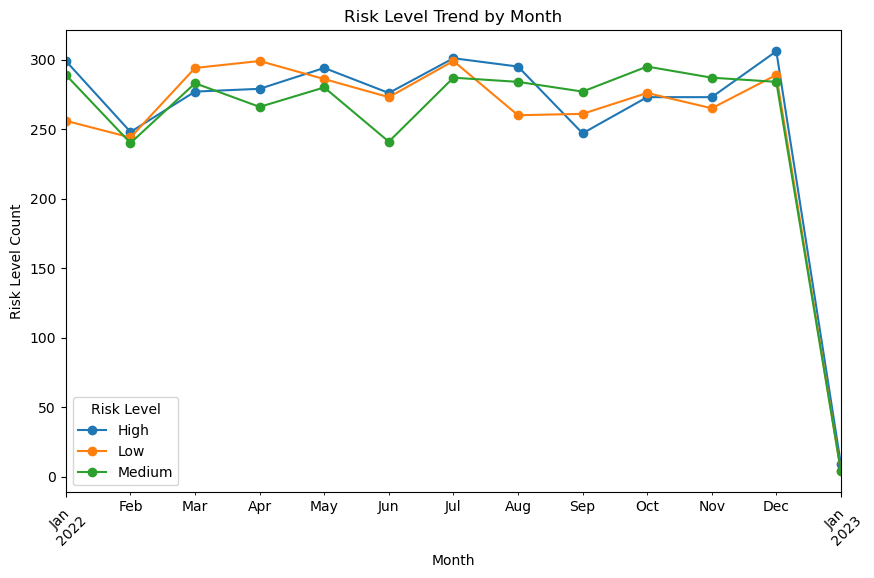

In [21]:
# Plot the data trend of risk levels by months
monthly_risk_counts.plot(marker='o', figsize=(10, 6))
plt.xlabel('Month')
plt.ylabel('Risk Level Count')
plt.title('Risk Level Trend by Month')
plt.xticks(rotation=45)
plt.legend(title='Risk Level')
plt.show()

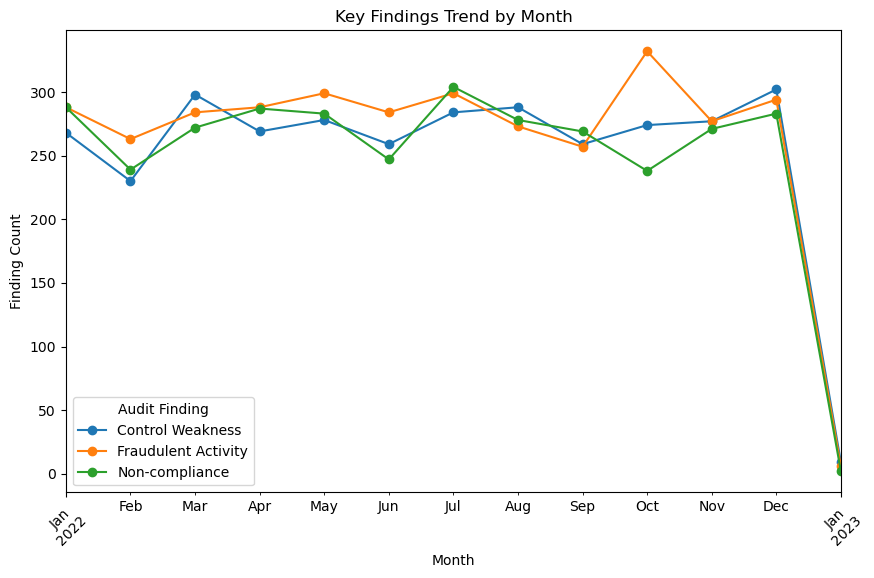

In [8]:
# Group the data by month and audit finding, and count the occurrences of each combination
monthly_findings_counts = audit_df.groupby([audit_df['Audit_Date'].dt.to_period('M'), 'Audit_Finding']).size().unstack()
# Plot the data trend of key findings by months
monthly_findings_counts.plot(marker='o', figsize=(10, 6))
plt.xlabel('Month')
plt.ylabel('Finding Count')
plt.title('Key Findings Trend by Month')
plt.xticks(rotation=45)
plt.legend(title='Audit Finding')
plt.show()

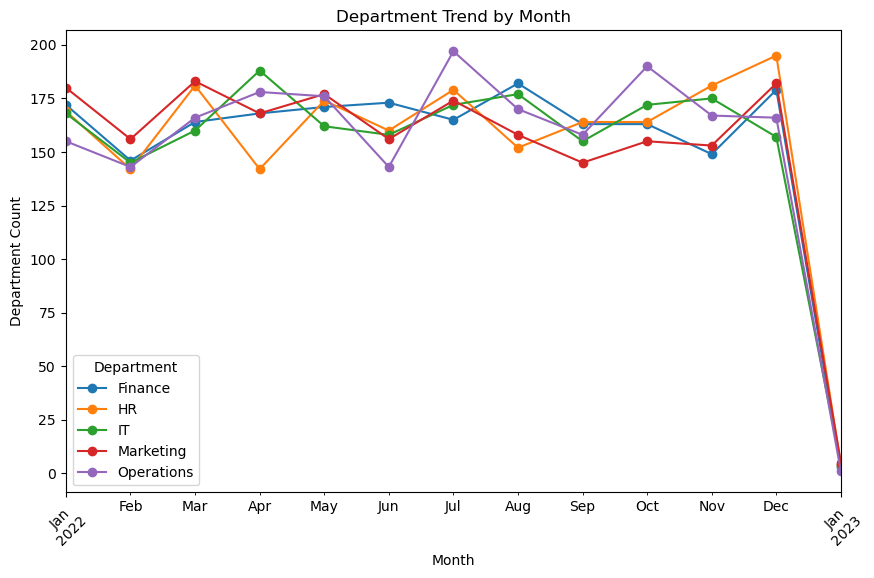

In [23]:
# Group the data by month and department, and count the occurrences of each combination
monthly_department_counts = audit_df.groupby([audit_df['Audit_Date'].dt.to_period('M'), 'Department']).size().unstack()

# Plot the data trend of departments by months
monthly_department_counts.plot(marker='o', figsize=(10, 6))
plt.xlabel('Month')
plt.ylabel('Department Count')
plt.title('Department Trend by Month')
plt.xticks(rotation=45)
plt.legend(title='Department')
plt.show()

In [9]:
# Create a new DataFrame with the counts of key findings, risk levels, and departments
counts_df = pd.DataFrame({
    'Key Findings': audit_df['Audit_Finding'].value_counts(),
    'Risk Levels': audit_df['Risk_Level'].value_counts(),
    'Departments': audit_df['Department'].value_counts()
})
display(counts_df)

,Key Findings,Risk Levels,Departments
Control Weakness,3295.0,NaN,NaN
Finance,NaN,NaN,1998.0
Fraudulent Activity,3444.0,NaN,NaN
HR,NaN,NaN,2007.0
High,NaN,3377.0,NaN
IT,NaN,NaN,1993.0
Low,NaN,3306.0,NaN
Marketing,NaN,NaN,1992.0
Medium,NaN,3317.0,NaN
Non-compliance,3261.0,NaN,NaN


In [4]:
# Correct column names based on likely actual names
features = ['Audit_Finding', 'Risk_Level']
encoded_df = pd.get_dummies(audit_df[features])

#encoded_df = pd.get_dummies(audit_df[['Audit_Finding', 'Risk_Level']], 
                             #prefix=['Audit_Finding', 'Risk_Level'])

# Calculate correlation matrix
correlation = encoded_df.corr()

print("Correlation matrix between One-Hot Encoded Audit Findings and Risk Level:")
display(correlation)


Correlation matrix between One-Hot Encoded Audit Findings and Risk Level:


,Audit_Finding_Control Weakness,Audit_Finding_Fraudulent Activity,Audit_Finding_Non-compliance,Risk_Level_High,Risk_Level_Low,Risk_Level_Medium
Audit_Finding_Control Weakness,1.000000,-0.508090,-0.487647,-0.014270,0.013420,0.000926
Audit_Finding_Fraudulent Activity,-0.508090,1.000000,-0.504185,0.004878,-0.010999,0.006090
Audit_Finding_Non-compliance,-0.487647,-0.504185,1.000000,0.009364,-0.002307,-0.007101
Risk_Level_High,-0.014270,0.004878,0.009364,1.000000,-0.501819,-0.503066
Risk_Level_Low,0.013420,-0.010999,-0.002307,-0.501819,1.000000,-0.495103
Risk_Level_Medium,0.000926,0.006090,-0.007101,-0.503066,-0.495103,1.000000


In [6]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset to work on
df_encoded = audit_df.copy()

# Encode categorical columns
label_encoders = {}
for column in ['Department', 'Audit_Finding', 'Risk_Level']:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

# Convert 'Audit_Date' to datetime and extract useful numerical features
df_encoded['Audit_Date'] = pd.to_datetime(df_encoded['Audit_Date'])
df_encoded['Audit_Year'] = df_encoded['Audit_Date'].dt.year
df_encoded['Audit_Month'] = df_encoded['Audit_Date'].dt.month

# Drop original date column for correlation
df_encoded = df_encoded.drop(columns=['Audit_Date'])

# Compute the correlation matrix
correlation_matrix = df_encoded.corr()

correlation_matrix


,Audit_ID,Department,Audit_Finding,Risk_Level,Audit_Year,Audit_Month
Audit_ID,1.000000,-0.002671,-0.004156,0.008544,0.000929,0.013431
Department,-0.002671,1.000000,-0.007240,0.006309,-0.005172,-0.002205
Audit_Finding,-0.004156,-0.007240,1.000000,-0.010598,-0.020813,-0.010860
Risk_Level,0.008544,0.006309,-0.010598,1.000000,-0.014532,0.008530
Audit_Year,0.000929,-0.005172,-0.020813,-0.014532,1.000000,-0.066110
Audit_Month,0.013431,-0.002205,-0.010860,0.008530,-0.066110,1.000000


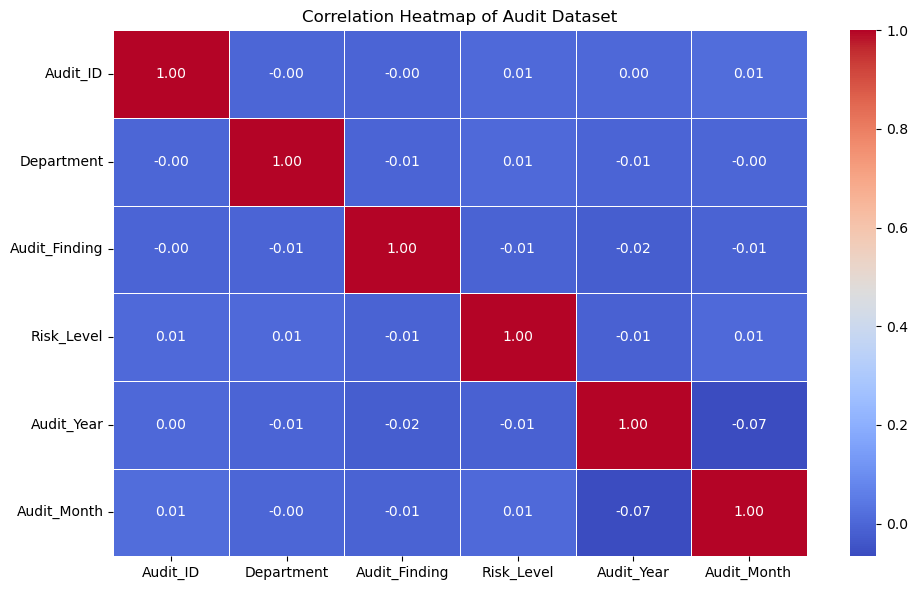

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Audit Dataset")
plt.tight_layout()
plt.show()


# Part 2. Machine learning

        - feature selection
        - categorical data handling
       
        
        - splitting data
        - train/test using:
            - K-Mean
              - PCA
            - Isolation Forest
            - Random Forest
            - Decision Tree
         
         - Comparison and Evaluations    
             - report

In [3]:
# Feature selection
features = ['Department', 'Risk_Level']
X = pd.get_dummies(audit_df[features], dtype=int)
display(X.head())

,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Operations,Risk_Level_High,Risk_Level_Low,Risk_Level_Medium
0,0,0,0,0,1,0,0,1
1,1,0,0,0,0,0,0,1
2,0,1,0,0,0,1,0,0
3,0,0,0,0,1,0,0,1
4,0,0,1,0,0,1,0,0


## K-MEAN

In [5]:
# Clustering using K-means
kmeans = KMeans(n_clusters=3, random_state=42)
audit_df['Cluster'] = kmeans.fit_predict(X)
display(audit_df.head())

,Audit_ID,Department,Audit_Finding,Risk_Level,Audit_Date,Cluster
0,1,Operations,Non-compliance,Medium,2022-03-23,0
1,2,Finance,Fraudulent Activity,Medium,2022-09-05,0
2,3,HR,Non-compliance,High,2022-09-03,1
3,4,Operations,Non-compliance,Medium,2022-03-27,0
4,5,IT,Control Weakness,High,2022-11-05,1


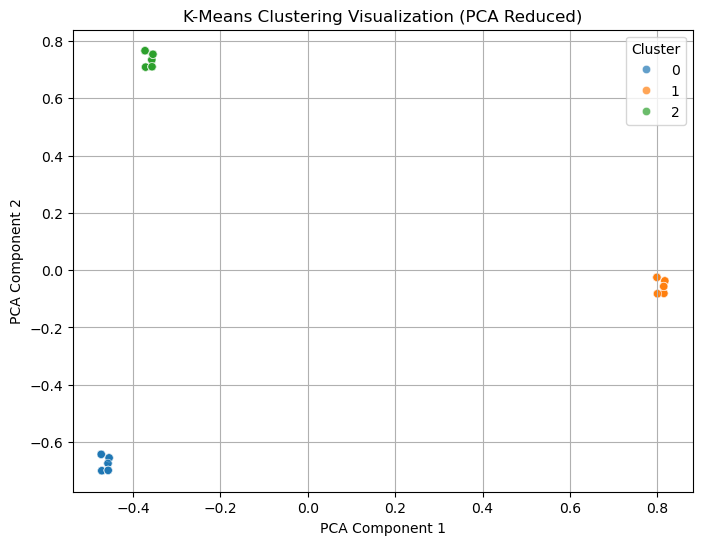

In [6]:
from sklearn.decomposition import PCA

# --- Reduce dimensionality to 2D for visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Add to DataFrame for easy plotting
audit_df['PCA1'] = X_pca[:, 0]
audit_df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=audit_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='tab10',
    alpha=0.7
)
plt.title('K-Means Clustering Visualization (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

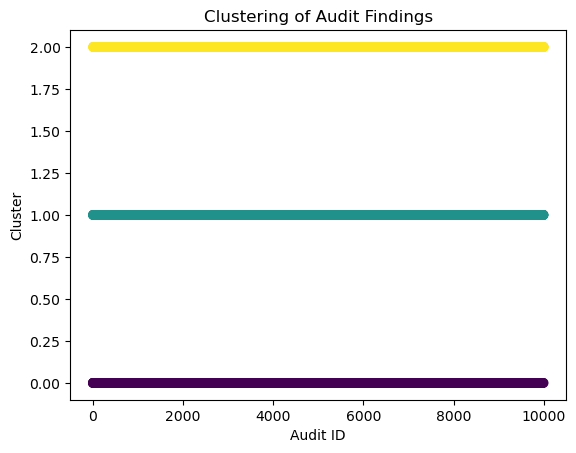

In [25]:
# Plotting the clusters
plt.scatter(audit_df['Audit_ID'], audit_df['Cluster'], c=audit_df['Cluster'], cmap='viridis')
plt.xlabel('Audit ID')
plt.ylabel('Cluster')
plt.title('Clustering of Audit Findings')
plt.show()

## Isolation Forest

In [7]:
# Prediction and Risk Assessment
# Selecting the features for analysis
features = ['Audit_ID', 'Cluster']
# Extracting the feature values
X = audit_df[features].values
kmeans = KMeans(n_clusters=3, random_state=42)
audit_df['Cluster'] = kmeans.fit_predict(X)

# Anomaly detection using Isolation Forest
isolation_forest = IsolationForest(contamination=0.1, random_state=42)
audit_df['Is_Anomaly'] = isolation_forest.fit_predict(X)

display(audit_df.head())

,Audit_ID,Department,Audit_Finding,Risk_Level,Audit_Date,Cluster,PCA1,PCA2,Is_Anomaly
0,1,Operations,Non-compliance,Medium,2022-03-23,2,-0.471459,-0.700113,-1
1,2,Finance,Fraudulent Activity,Medium,2022-09-05,2,-0.456789,-0.698802,-1
2,3,HR,Non-compliance,High,2022-09-03,2,0.816938,-0.037508,-1
3,4,Operations,Non-compliance,Medium,2022-03-27,2,-0.471459,-0.700113,-1
4,5,IT,Control Weakness,High,2022-11-05,2,0.814391,-0.056822,-1


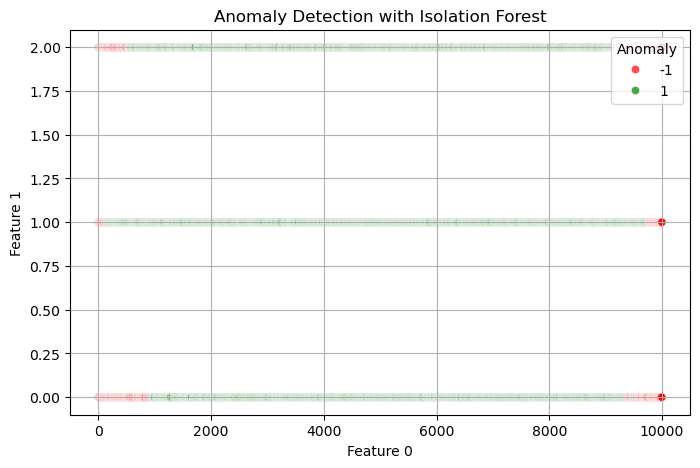

In [9]:
# --- 1. Visualize Anomalies ---
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=audit_df['Is_Anomaly'],
    palette={1: 'green', -1: 'red'},
    alpha=0.7
)
plt.title('Anomaly Detection with Isolation Forest')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.legend(title='Anomaly')
plt.grid(True)
plt.show()


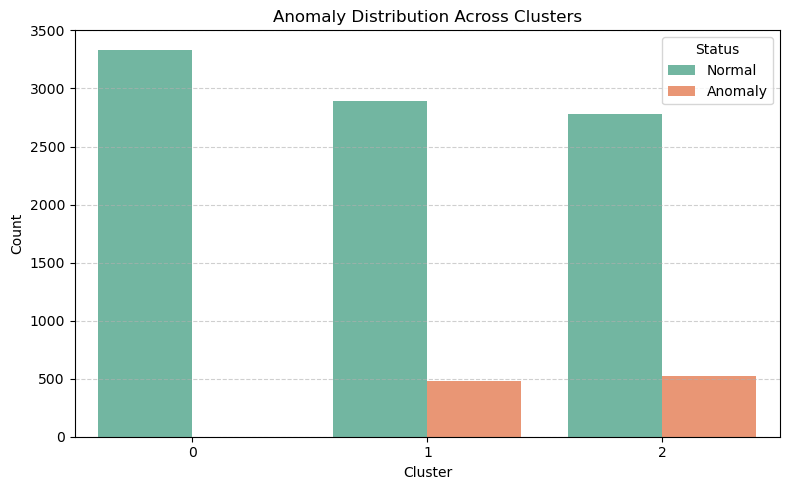

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Map anomaly values to readable labels
audit_df['Anomaly_Label'] = audit_df['Is_Anomaly'].map({1: 'Normal', -1: 'Anomaly'})

plt.figure(figsize=(8, 5))
sns.countplot(data=audit_df, x='Cluster', hue='Anomaly_Label', palette='Set2')
plt.title('Anomaly Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Anomaly Distribution Across Clusters.png", dpi=300, bbox_inches='tight')  # Saves the plot
plt.show()


## Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split

features = ['Department', 'Risk_Level']
X = pd.get_dummies(audit_df[features], dtype=int)
y = audit_df['Audit_Finding'] 

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rand_forest = RandomForestClassifier(n_estimators=10, random_state=42)
rand_forest.fit(X_train, y_train)

# Predict & evaluate
y_pred = rand_forest.predict(X_test)


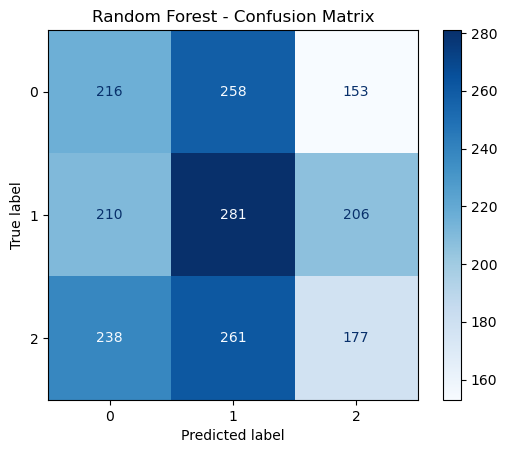

Random Forest Accuracy: 0.34
Random Forest Classification Report:
Random Forest Classification Report:
                     precision    recall  f1-score   support
Control Weakness      0.325301  0.344498  0.334624   627.000
Fraudulent Activity   0.351250  0.403156  0.375418   697.000
Non-compliance        0.330224  0.261834  0.292079   676.000
accuracy              0.337000  0.337000  0.337000     0.337
macro avg             0.335592  0.336496  0.334040  2000.000
weighted avg          0.336008  0.337000  0.334460  2000.000


In [48]:
y_test_pred = rand_forest.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.grid(False)
plt.show()

rand_forest_acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {rand_forest_acc:.2f}")

print("Random Forest Classification Report:")
# Generate classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the dictionary into a DataFrame
df_report = pd.DataFrame(report).transpose()

# Export the DataFrame to a CSV file
df_report.to_csv('random_forest_classification_report.csv')

# Display the DataFrame
print("Random Forest Classification Report:")
print(df_report)

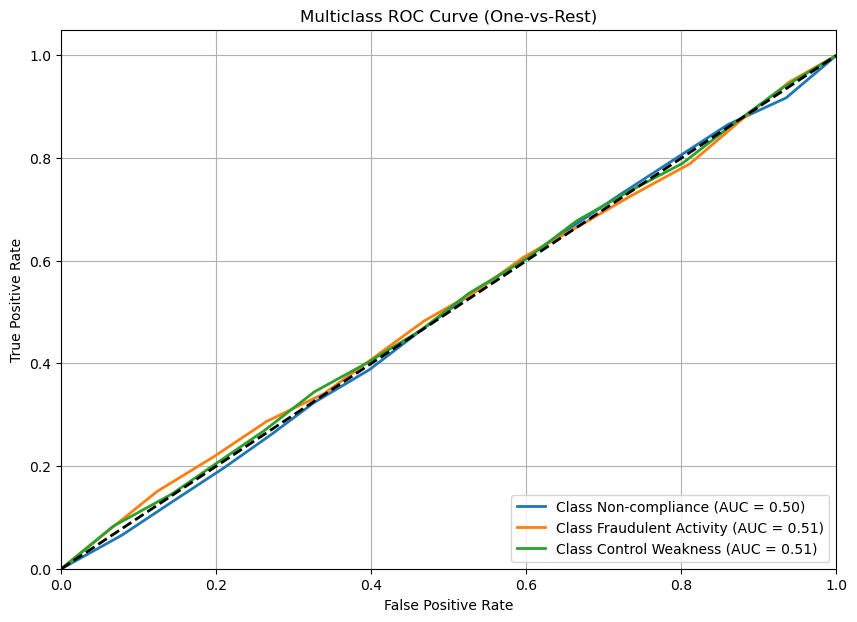

In [45]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output
classes = y.unique()
y_bin = label_binarize(y, classes=classes)
n_classes = y_bin.shape[1]

# Train/test split on the binarized labels
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# One-vs-Rest classifier
ovr = OneVsRestClassifier(RandomForestClassifier(n_estimators=10, random_state=42))
ovr.fit(X_train, y_train_bin)
y_score = ovr.predict_proba(X_test)

# Plot ROC curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


## Decision Tree Model

In [46]:
# Training a decision tree classifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)

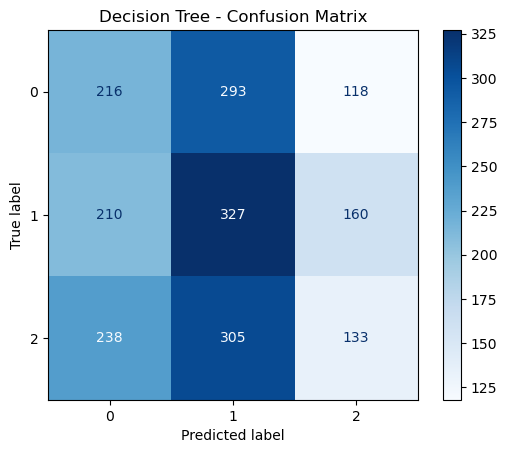

Decision Tree Accuracy: 0.34
                     precision    recall  f1-score   support

   Control Weakness       0.33      0.34      0.33       627
Fraudulent Activity       0.35      0.40      0.38       697
     Non-compliance       0.33      0.26      0.29       676

           accuracy                           0.34      2000
          macro avg       0.34      0.34      0.33      2000
       weighted avg       0.34      0.34      0.33      2000

                     precision    recall  f1-score   support
Control Weakness      0.325301  0.344498  0.334624   627.000
Fraudulent Activity   0.351250  0.403156  0.375418   697.000
Non-compliance        0.330224  0.261834  0.292079   676.000
accuracy              0.337000  0.337000  0.337000     0.337
macro avg             0.335592  0.336496  0.334040  2000.000
weighted avg          0.336008  0.337000  0.334460  2000.000


In [47]:
y_test_pred = dtree.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.grid(False)
plt.show()

tree_acc = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {tree_acc:.2f}")

# Classification report
print(classification_report(y_test, y_pred))

# Generate classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the dictionary into a DataFrame
df_report = pd.DataFrame(report).transpose()

# Export the DataFrame to a CSV file
df_report.to_csv('classification_reportdt.csv')

# Display the DataFrame
print(df_report)

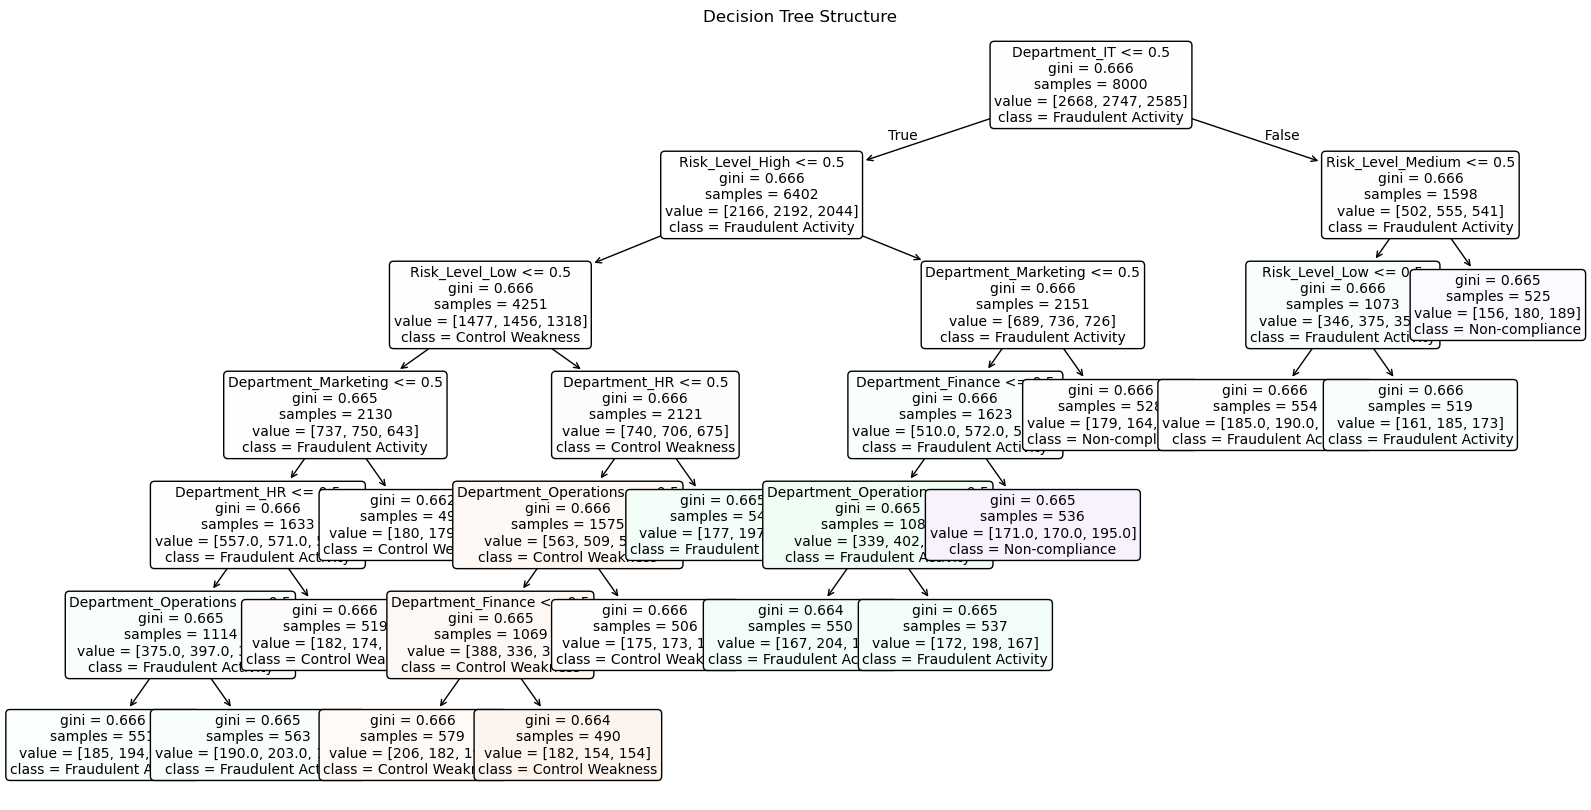

In [51]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dtree, feature_names=X.columns, class_names=[str(c) for c in dtree.classes_],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.show()

## Model Comparison:
- ROC and AUC
- Accuracy

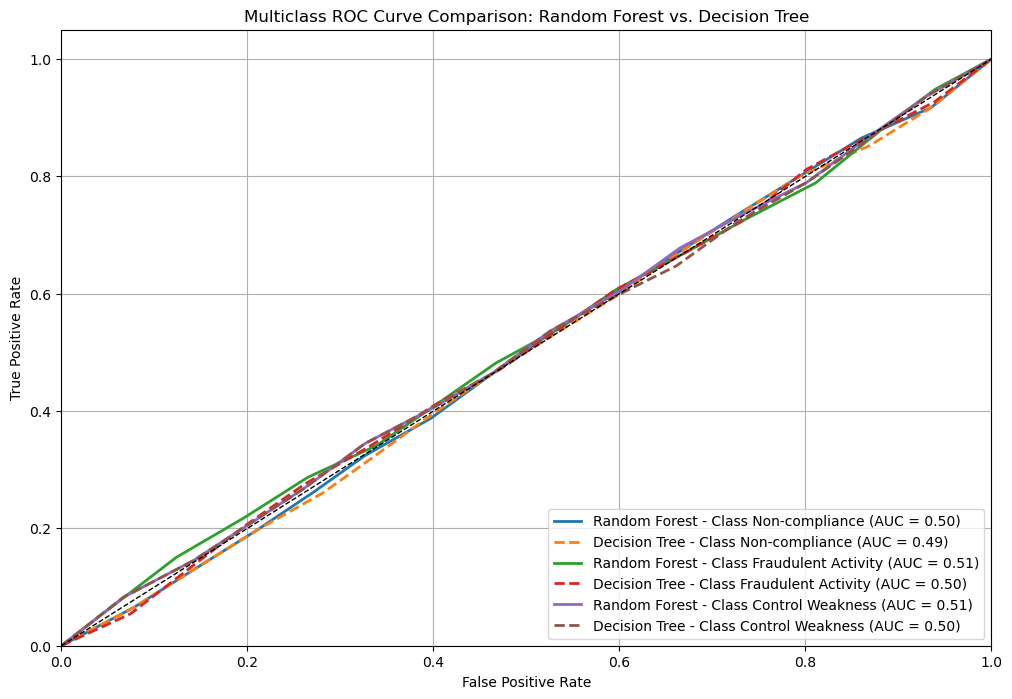

In [52]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output labels
classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Get probabilities from both models (using One-vs-Rest)
ovr_rf = OneVsRestClassifier(rand_forest)
ovr_tree = OneVsRestClassifier(dtree)

# Fit them on training data
ovr_rf.fit(X_train, label_binarize(y_train, classes=classes))
ovr_tree.fit(X_train, label_binarize(y_train, classes=classes))

# Predict probabilities
y_score_rf = ovr_rf.predict_proba(X_test)
y_score_tree = ovr_tree.predict_proba(X_test)

# Prepare to plot ROC curves for each class
fpr_rf, tpr_rf, roc_auc_rf = dict(), dict(), dict()
fpr_tree, tpr_tree, roc_auc_tree = dict(), dict(), dict()

for i in range(n_classes):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

    fpr_tree[i], tpr_tree[i], _ = roc_curve(y_test_bin[:, i], y_score_tree[:, i])
    roc_auc_tree[i] = auc(fpr_tree[i], tpr_tree[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))

for i in range(n_classes):
    plt.plot(fpr_rf[i], tpr_rf[i], lw=2,
             label=f'Random Forest - Class {classes[i]} (AUC = {roc_auc_rf[i]:.2f})')
    plt.plot(fpr_tree[i], tpr_tree[i], lw=2, linestyle='--',
             label=f'Decision Tree - Class {classes[i]} (AUC = {roc_auc_tree[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve Comparison: Random Forest vs. Decision Tree')
plt.legend(loc='lower right')
plt.grid()
plt.show()


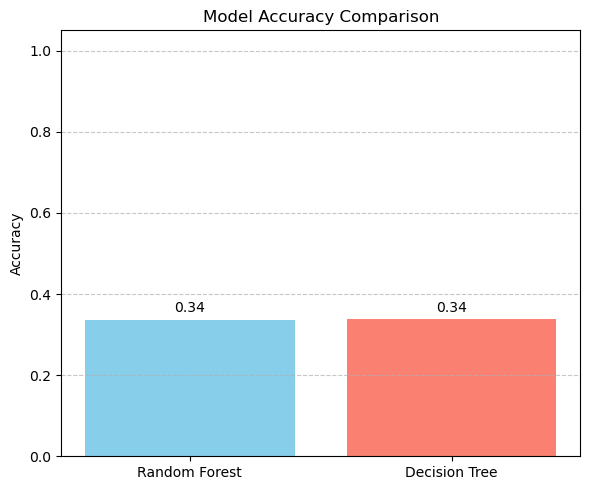

In [54]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
acc_rf = accuracy_score(y_test, y_pred)
acc_tree = accuracy_score(y_test, y_pred_tree)


import matplotlib.pyplot as plt

# Model names and scores
models = ['Random Forest', 'Decision Tree']
accuracies = [acc_rf, acc_tree]

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'salmon'])

# Labels & formatting
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()



## HYPERPARAMETER TUNING

In [13]:
# Re-import required libraries after code execution state reset
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the dataset
df = pd.read_csv('audit_dataset.csv')

# Preprocessing
df['Audit_Date'] = pd.to_datetime(df['Audit_Date'])
df['Year'] = df['Audit_Date'].dt.year
df['Month'] = df['Audit_Date'].dt.month
df['Day'] = df['Audit_Date'].dt.day
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Risk_Level_Encoded'] = df['Risk_Level'].map(risk_map)
df_encoded = pd.get_dummies(df[['Department', 'Audit_Finding']])
features = pd.concat([df[['Year', 'Month', 'Day', 'Risk_Level_Encoded']], df_encoded], axis=1)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(features)

# Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(features)

# Classification
le_finding = LabelEncoder()
df['Finding_Label'] = le_finding.fit_transform(df['Audit_Finding'])
X_train, X_test, y_train, y_test = train_test_split(features, df['Finding_Label'], test_size=0.3, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
rf_model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

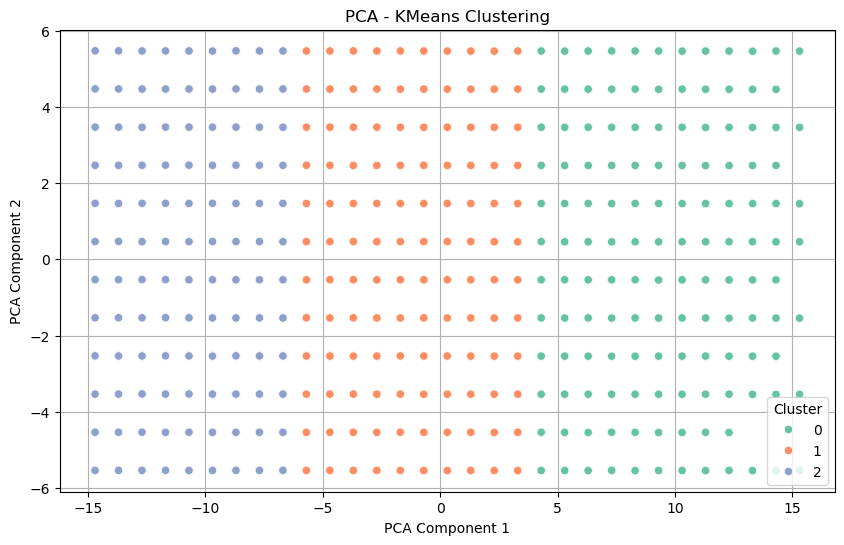

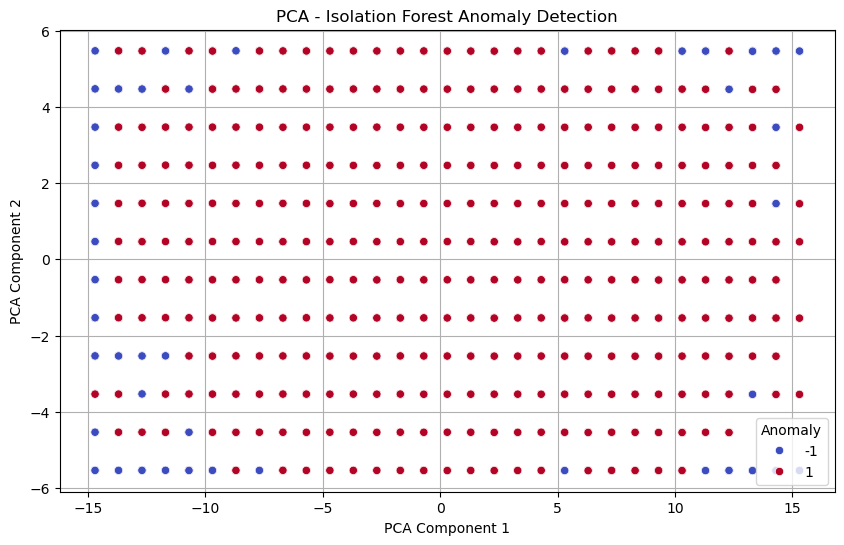

In [14]:
# PCA Plot with Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['Cluster'], palette='Set2')
plt.title('PCA - KMeans Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Anomalies on PCA plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['Anomaly'], palette='coolwarm')
plt.title('PCA - Isolation Forest Anomaly Detection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Anomaly')
plt.grid(True)
plt.show()


In [37]:
from sklearn.metrics import classification_report
import pandas as pd

# Assuming y_test, y_pred_dt, y_pred_rf, and le_finding are already defined

# Generate classification reports as dictionaries
report_dt = classification_report(y_test, y_pred_dt, target_names=le_finding.classes_, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=le_finding.classes_, output_dict=True)

# Convert the dictionaries into DataFrames
df_dt = pd.DataFrame(report_dt).transpose()
df_rf = pd.DataFrame(report_rf).transpose()

# Merge the DataFrames to create a comparison table
df_comparison = pd.merge(df_dt, df_rf, left_index=True, right_index=True, suffixes=('_Decision Tree', '_Random Forest'))

# Export the comparison table to a CSV file
df_comparison.to_csv('classification_comparison.csv')

# Display the comparison table
display(df_comparison)


,precision_Decision Tree,recall_Decision Tree,f1-score_Decision Tree,support_Decision Tree,precision_Random Forest,recall_Random Forest,f1-score_Random Forest,support_Random Forest
Control Weakness,1.0,1.0,1.0,981.0,1.0,1.0,1.0,981.0
Fraudulent Activity,1.0,1.0,1.0,1033.0,1.0,1.0,1.0,1033.0
Non-compliance,1.0,1.0,1.0,986.0,1.0,1.0,1.0,986.0
accuracy,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,3000.0,1.0,1.0,1.0,3000.0
weighted avg,1.0,1.0,1.0,3000.0,1.0,1.0,1.0,3000.0


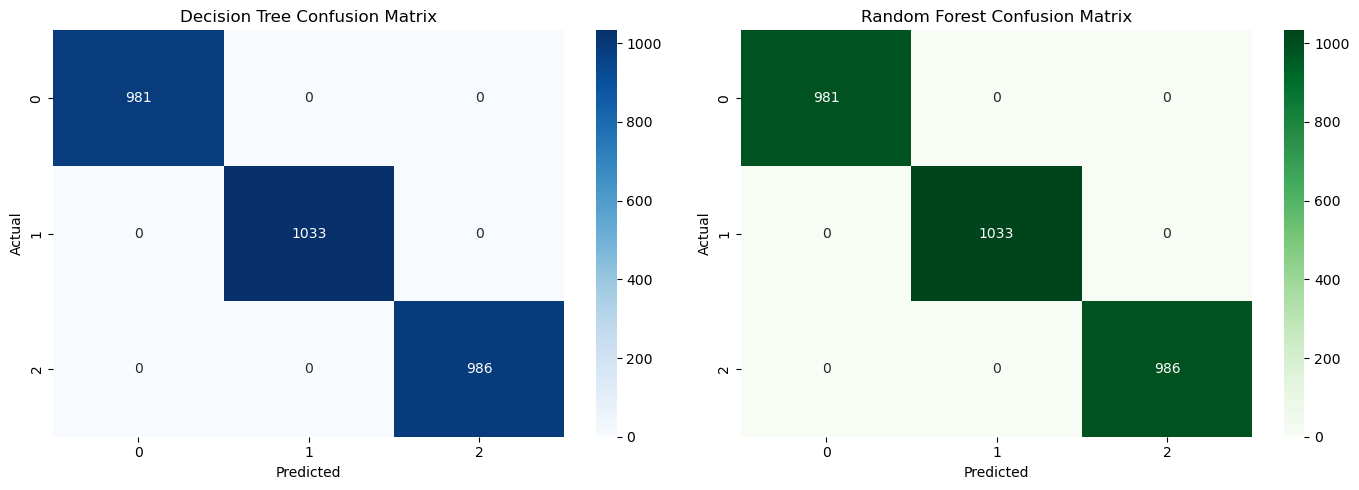

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()


## 2.3 Summary
   
    For the data preprocessing:
      1. Preprocessing followed, including the encoding of categorical variables and extraction of date-based features
      2. PCA was then used to reduce the feature space for more effective clustering and visualization
      
    For Machine Learning Models: (1) k-Mean and Isolation Forest  (2) Decision Tree (3) Random Forest 
     1. k-Mean and Isolation Forest
     - K-Means clustering algorithm successfully segmented the dataset into three distinct groups
     - Anomaly detection, flagged approximately 10% of the audit records
     
     2. Accuracy. 
        - Decision Tree=34%
        - Random Forest=34%
        
     3. Retrained all three models using tuned parameters, now had a higher accuracy (100%). 
     
        - Decision Tree,  accuracy = 100% 
        - Random Forest, accuracy = 100%
        - Both achieved the same results after comparing the ROC/AUC. 


    However, I skipped:
        - imbalanced data handling (not happened for this dataset)
        - feature selection (remove some less important)
        

    
    What next: 
     - pipeline (use function for code reuse)
     - get more data
     - get more features
     - add more algorithms
     - visualize the feature interaction with target using SHAP
  